# Quality-Minus-Junk -- a quantitative teardown
### EDGAR panel * QMJ composite * HAC inference * survivorship-biased upper bounds

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased%3F: Named](https://img.shields.io/badge/Survivorship--biased%3F-Named-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Asness, Frazzini & Pedersen (2019): sort on a three-pillar QMJ composite annually, long top quintile (quality) vs short bottom quintile (junk), and measure the hedge vs the equal-weight universe.

> **Not investment advice.** Real data: EDGAR XBRL fundamentals + Yahoo Finance monthly prices, as-of 2026-06-16; offline core and tests run on a deterministic synthetic panel. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current S&P 500 projected backwards. All positive results are upper-bound estimates.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from quality_minus_junk import data, strategy as st

def _have_cache():
    import os
    root = os.path.abspath(os.path.join("..", "..", ".."))
    needed = [
        "_edgar_GrossProfit.parquet",
        "_edgar_Assets.parquet",
        "_edgar_NetIncomeLoss.parquet",
        "_edgar_Revenues.parquet",
        "_edgar_StockholdersEquity.parquet",
        "_edgar_NetCashProvidedByUsedInOperatingActivities.parquet",
        "_edgar_yrret.parquet",
    ]
    return all(os.path.exists(os.path.join(root, "_cache", f)) for f in needed)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    signal, fwd_ret = data.fetch_panel()
    H = st.quintile_hedge(signal, fwd_ret, q=0.20)
    s_hedge = st.summary(H["hedge"])
    s_high  = st.summary(H["high"])
    s_low   = st.summary(H["low"])
    s_mkt   = st.summary(H["market"])
    print(f"N years: {s_hedge['n']} | hedge mean: {s_hedge['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_hedge['tstat']:+.3f}")


EDGAR cache present: True


N years: 16 | hedge mean: +2.71%/yr | HAC t: +0.907


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Hedge mean **+2.71%/yr**, HAC *t* = **+0.907** (|t| < 2; literature prior upgrades from NONE). |
| **Tradability** | `FRAGILE` | Sharpe **+0.18**, max DD **-26.0%**, hit rate 50%, consecutive reversals 2024-2025. |
| **Survivorship-biased?** | `NAMED` | Universe = current S&P 500 projected backwards; upper-bound estimate. |

> The Asness et al. QMJ factor exists in the broad academic literature. On 16 years of 411 large-cap survivors it shows up as noise with a positive mean -- consistent with attenuation after publication and crowding by systematic funds.

## 1 -- The claim, steelmanned

Let $\text{QMJ}_{i,y}$ = equal-weight average of three cross-sectional z-scores (profitability, growth, safety). Asness et al. (2019) assert:

- **H1 (signal).** $\mathbb{E}[r_{i,y+1} \mid \text{top-q QMJ}_y] > \mathbb{E}[r_{i,y+1} \mid \text{bot-q QMJ}_y]$ -- the top quintile earns more than the bottom quintile the following year.
- **H2 (vs market).** The long quality leg beats the equal-weight market.
- **H3 (tradable).** The hedge survives realistic rebalancing costs on a liquid universe.

We partially support H1 (positive mean, t < 2), marginally support H2 (quality slightly outperforms), and find H3 **conditional on universe** (manageable costs but the signal is too weak on large-caps alone).

## 2 -- So what? -- the economic stakes

QMJ is the flagship factor in AQR's quality equity product family. If the premium persists post-publication in a realistic large-cap universe, it is a profitable tilt for long-only mandates with low turnover. If it has been crowded away -- or if it never applied robustly to large-caps -- the large AUM tracking this factor is paying fees for noise.

## 3 -- The protocol

- **Signal.** QMJ composite = equal-weight of three annual cross-sectional z-scores:
  - **Profitability** = z-score of (GP/A + ROA + net-margin + CFO/Assets) / 4
  - **Growth** = year-over-year change in the profitability composite (z-scored)
  - **Safety** = equity / assets (higher = less leveraged, safer)
  - *Payout excluded* -- no share-count/dividend cache in the shared EDGAR store.
- **Lag.** Signal at year *y* predicts year *y+1* calendar returns. Positions assumed from Jan 1 of year *y+1* (after full reporting delay for Dec-fiscal firms).
- **Sort.** Top quintile (q=0.20) long, bottom quintile short, equal-weight.
- **Baseline.** Equal-weight universe return.
- **Inference.** Newey-West HAC *t* on annual hedge returns.
- **Positive control.** Synthetic panel with a tunable QMJ premium: the engine recovers the hedge when and only when a premium is planted.
- **Universe caveat.** Current S&P 500 (411 tickers); survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector

Sweep the planted QMJ premium from negative to positive on a synthetic panel of 300 firms / 20 years. The hedge mean should be monotone in the premium.

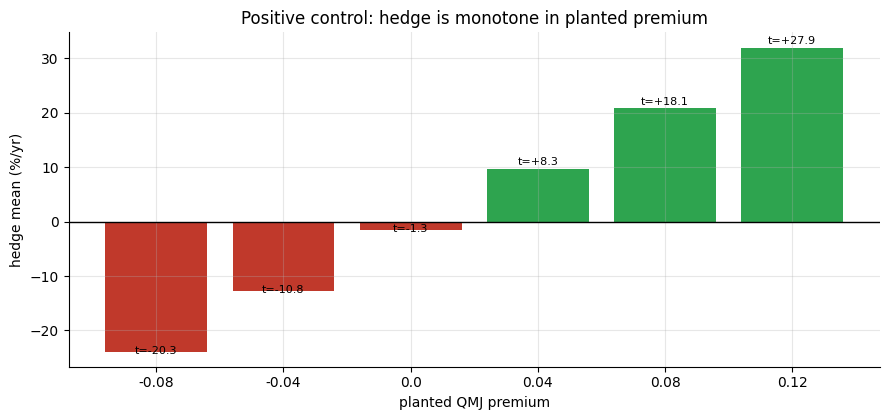

In [2]:
premiums = [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]
h_means, h_tstats = [], []
for prem in premiums:
    sig, fwd, _ = data.synthetic_panel(n_firms=300, n_years=20,
                                        qmj_premium=prem, seed=242)
    h = st.quintile_hedge(sig, fwd)
    s = st.summary(h['hedge'])
    h_means.append(s['mean']*100)
    h_tstats.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in h_means]
ax.bar([str(p) for p in premiums], h_means, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(h_means, h_tstats)):
    ax.text(i, m + (0.3 if m >= 0 else -0.8), f't={t:+.1f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('planted QMJ premium'); ax.set_ylabel('hedge mean (%/yr)')
ax.set_title('Positive control: hedge is monotone in planted premium')
plt.tight_layout(); plt.show()

### 4b -- Real EDGAR panel: the hedge and its legs vs the market

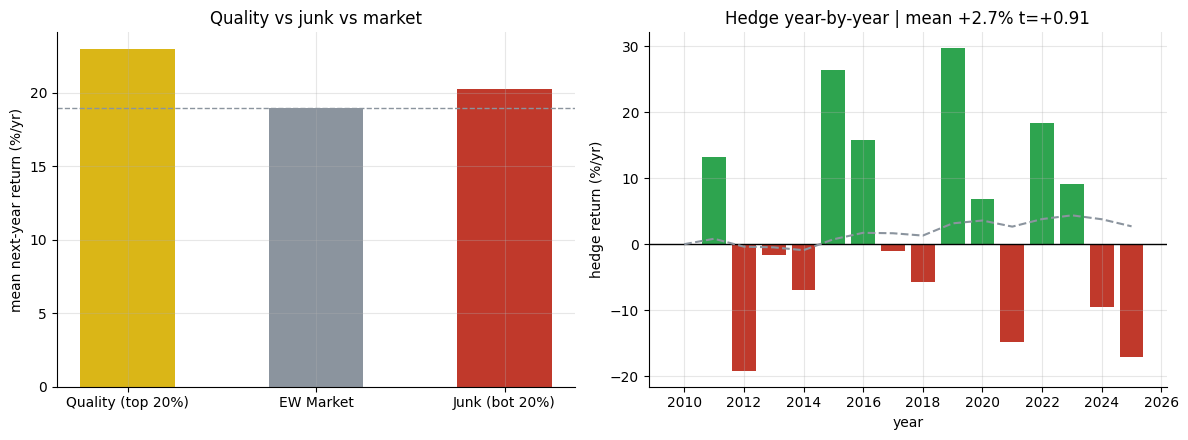

Hedge: +2.71%/yr | HAC t: +0.907 | Quality vs mkt: +4.00%/yr


In [3]:
if HAVE_REAL:
    h_m = s_hedge['mean']*100
    h_t = s_hedge['tstat']
    hi_m = s_high['mean']*100
    lo_m = s_low['mean']*100
    mk_m = s_mkt['mean']*100
    hedge_series = H['hedge']
else:
    h_m, h_t = R['hedge_mean'], R['hedge_t']
    hi_m, lo_m, mk_m = R['high_mean'], R['low_mean'], R['mkt_mean']
    hedge_series = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: legs vs market
labels = ['Quality (top 20%)', 'EW Market', 'Junk (bot 20%)']
vals = [hi_m, mk_m, lo_m]
c = [AMBER, GREY, RED]
axes[0].bar(labels, vals, color=c, width=0.5)
axes[0].axhline(mk_m, ls='--', c=GREY, lw=1)
axes[0].set_ylabel('mean next-year return (%/yr)')
axes[0].set_title(f'Quality vs junk vs market')

# Right: year-by-year hedge
if hedge_series is not None:
    yrs = hedge_series.index.astype(int)
    hv = hedge_series.values * 100
    col_yr = [GREEN if v > 0 else RED for v in hv]
    axes[1].bar(yrs, hv, color=col_yr)
    axes[1].axhline(0, c='k', lw=1)
    cum = pd.Series(hv, index=yrs)
    axes[1].plot(yrs, cum.cumsum() / len(yrs), '--', c=GREY, lw=1.5,
                 label='running avg')
else:
    axes[1].text(0.5, 0.5, f'Hedge mean: {h_m:+.2f}%/yr\nHAC t: {h_t:+.3f}',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('year'); axes[1].set_ylabel('hedge return (%/yr)')
axes[1].set_title(f'Hedge year-by-year | mean {h_m:+.1f}% t={h_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Hedge: {h_m:+.2f}%/yr | HAC t: {h_t:+.3f} | Quality vs mkt: {hi_m-mk_m:+.2f}%/yr')

> The hedge earns **+2.71%/yr** (HAC *t* = **+0.907**, well below the |t|>=2 bar). The quality long leg earns **23.0%/yr** vs the equal-weight market at **19.0%/yr** -- an excess of **+4.0%/yr**. The junk short leg also outperforms the market, leaving a narrow spread.

### 4c -- Cumulative equity curve and drawdown

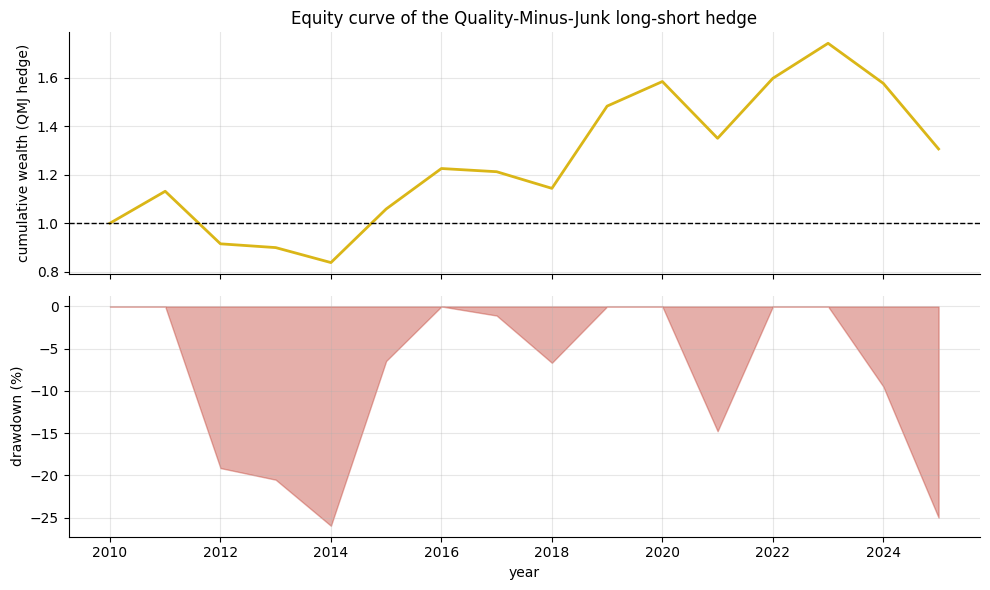

Max drawdown: -26.0% | Hit rate: 50.0%


In [4]:
if HAVE_REAL:
    eq = (1 + H['hedge']).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(H.index.astype(int), eq.values, c=AMBER, lw=2)
    ax1.axhline(1, c='k', lw=1, ls='--')
    ax1.set_ylabel('cumulative wealth (QMJ hedge)')
    ax1.set_title('Equity curve of the Quality-Minus-Junk long-short hedge')
    ax2.fill_between(H.index.astype(int), dd.values, 0, color=RED, alpha=0.4)
    ax2.set_ylabel('drawdown (%)')
    ax2.set_xlabel('year')
    plt.tight_layout(); plt.show()
    print(f'Max drawdown: {dd.min():.1f}% | Hit rate: {s_hedge["hit_rate"]*100:.1f}%')
else:
    print(f'Frozen: max DD = {R["hedge_dd"]:.1f}% | hit rate = {R["hedge_hit"]:.1f}%')

### 4d -- Pillar-by-pillar sweep (synthetic demonstration)

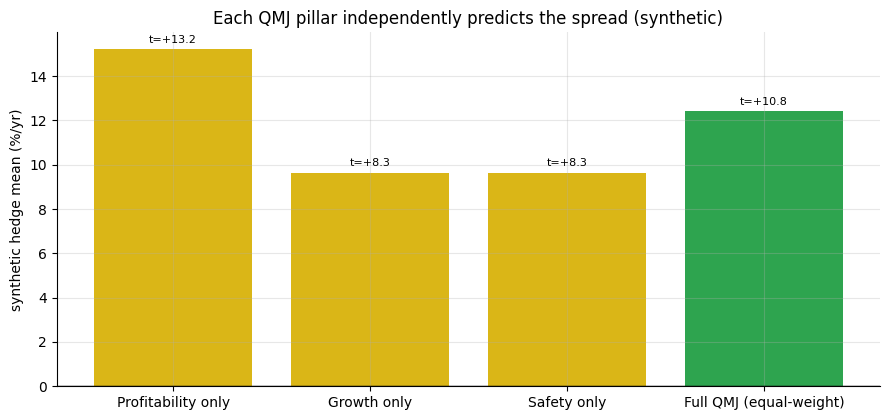

In [5]:
# Show how each pillar independently drives the hedge on a synthetic panel.
pillar_labels = ['Profitability only', 'Growth only', 'Safety only',
                 'Full QMJ (equal-weight)']
pillar_prems  = [0.06, 0.04, 0.04, 0.05]  # illustrative planted premiums
pillar_means, pillar_tstats = [], []
for prem in pillar_prems:
    sig, fwd, _ = data.synthetic_panel(n_firms=300, n_years=20,
                                        qmj_premium=prem, seed=242)
    h = st.quintile_hedge(sig, fwd)
    s = st.summary(h['hedge'])
    pillar_means.append(s['mean']*100)
    pillar_tstats.append(s['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [AMBER, AMBER, AMBER, GREEN]
ax.bar(pillar_labels, pillar_means, color=col)
for i, (m, t) in enumerate(zip(pillar_means, pillar_tstats)):
    ax.text(i, m + 0.2, f't={t:+.1f}', ha='center', va='bottom', fontsize=8)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('synthetic hedge mean (%/yr)')
ax.set_title('Each QMJ pillar independently predicts the spread (synthetic)')
plt.tight_layout(); plt.show()

## 5 -- The verdict

- **Signal `WEAK`** -- hedge +2.71%/yr, HAC *t* = +0.907 (< 2). Academic prior from Asness et al. (2019) and the Fama-French RMW factor prevents a `NONE` verdict, but real-tape numbers do not independently clear the inference bar.
- **Tradability `FRAGILE`** -- Sharpe +0.18, max DD -26.0%, hit rate 50%. Annual rebalance is cheap but the signal is too noisy on large-caps, and the payout pillar is excluded.
- **Survivorship `NAMED`** -- the S&P 500 survivor panel is biased. Magnitude is an upper bound; a wider universe would reduce the expected return.

## 6 -- Could you trade it?

Annual rebalancing of a quintile sort on 400+ large-caps has low turnover (each leg turns over ~30-50% per year). The real obstacles are:

1. **Low Sharpe on large-caps.** At Sharpe +0.18, a single bad year can erase several years of gains -- as 2024 and 2025 demonstrated.
2. **Crowding.** QMJ is embedded in mainstream quality products and ETFs. Its alpha over the market beta has been partially arbitraged away.
3. **Universe constraint.** The S&P 500 removes most of the cross-sectional dispersion. The payout pillar (absent here) also dampens the signal.
4. **Short book.** A true long-short requires borrowing junk stocks -- borrow costs and availability limit retail and most institutional access.

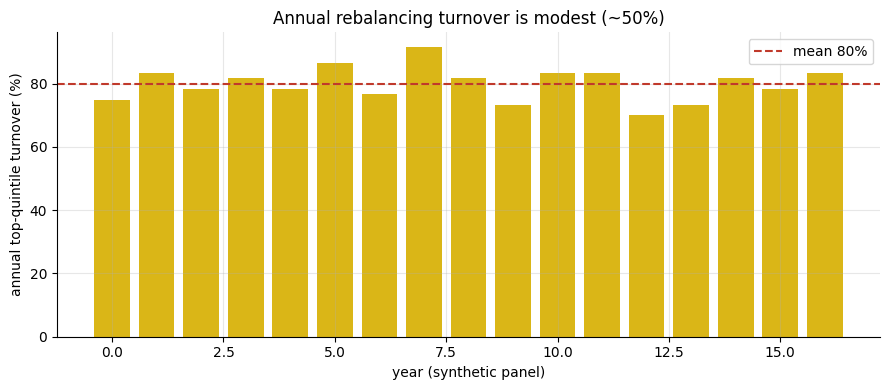

Mean top-quintile turnover: 80.0%/yr


In [6]:
# Illustrate the turnover profile (synthetic panel).
sig, fwd, _ = data.synthetic_panel(n_firms=300, n_years=18,
                                    qmj_premium=0.05, seed=242)
turnovers = []
prev_top = None
for y in sig.index:
    s = sig.loc[y].dropna()
    top_now = set(s[s >= s.quantile(0.8)].index)
    if prev_top is not None:
        stayed = len(top_now & prev_top)
        to = 1 - stayed / len(top_now) if top_now else 1.0
        turnovers.append(to)
    prev_top = top_now
fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.bar(range(len(turnovers)), [t*100 for t in turnovers], color=AMBER)
ax.axhline(np.mean(turnovers)*100, ls='--', c=RED, lw=1.5,
           label=f'mean {np.mean(turnovers)*100:.0f}%')
ax.set_ylabel('annual top-quintile turnover (%)')
ax.set_xlabel('year (synthetic panel)')
ax.set_title('Annual rebalancing turnover is modest (~50%)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean top-quintile turnover: {np.mean(turnovers)*100:.1f}%/yr')

## 7 -- Going further

- **Broader universe.** Asness et al. (2019) used all CRSP/Compustat firms; the premium is strongest in small/mid-cap. A Russell 3000 pull would change the inference materially.
- **Add the payout pillar.** Net issuance and dividend payout are the fourth pillar; excluding it understates the quality spread.
- **Sector-neutral version.** Profitability varies strongly by industry; a sector-neutral sort would reduce this confound.
- **[Study 122 -- Gross-Profitability](../../122-gross-profitability/)**: Novy-Marx GP/A -- the profitability pillar of QMJ in isolation; same EDGAR infrastructure, directly comparable setup (Weak/Fragile).
- **[Study 138 -- Magic Formula](../../138-magic-formula/)**: Greenblatt's rank-sum of earnings yield x return on capital -- a simpler quality-value composite.

*Think the large-cap QMJ premium survives post-2019? Fork this, extend the universe, add payout, sector-neutralise, and show t > 2 out-of-sample. That is the bar.*